In [1]:
import torch
import torch.nn.functional as F
import os
import tifffile
import matplotlib.pyplot as plt
import numpy as np
import torch
from models.skip1d import*
from tqdm.notebook import tqdm
import time
from matplotlib.patches import Rectangle

def pair_downsampler(img):
    #img has shape B C H W
    c = img.shape[1]

    filter1 = torch.FloatTensor([[[[0 ,0.5],[0.5, 0]]]]).to(img.device)
    filter1 = filter1.repeat(c,1, 1, 1)

    filter2 = torch.FloatTensor([[[[0.5 ,0],[0, 0.5]]]]).to(img.device)
    filter2 = filter2.repeat(c,1, 1, 1)

    output1 = F.conv2d(img, filter1, stride=2, groups=c)
    output2 = F.conv2d(img, filter2, stride=2, groups=c)

    return output1, output2


device = 'cpu'
torch.set_default_dtype(torch.float32)

base_path = "E:\\Voltron2_part1\\Voltron_Cell1"

tif_file = next((f for f in os.listdir(base_path) if f.endswith(".tif")), None)

tif_path = os.path.join(base_path, tif_file)

# Read TIFF file
vol_data = tifffile.imread(tif_path)  # shape: (T, H, W) or (H, W)

# Normalize the full video globally
full_video = torch.tensor(vol_data.astype(np.float32), dtype=torch.float32)
mean_val = full_video.mean()
std_val = full_video.std()

full_video_norm = (full_video - mean_val) / std_val

# Subsample 200 frames
video_tensor = full_video_norm[800:1800]

H, W, T = video_tensor.shape[1], video_tensor.shape[2], video_tensor.shape[0]

# Initialize lists to hold frames
downsampled_video1 = []
downsampled_video2 = []

for t in range(T):
    frame = video_tensor[t].unsqueeze(0).unsqueeze(0).to(device)  # [1, 1, H, W]
    ds1, ds2 = pair_downsampler(frame)  # [1, 1, H/2, W/2]
    downsampled_video1.append(torch.squeeze(ds1))  # [1, H/2, W/2]
    downsampled_video2.append(torch.squeeze(ds2))  # [1, H/2, W/2]

downsampled_video1 = torch.stack(downsampled_video1, dim=0)

print(video_tensor.shape)
print(downsampled_video1.shape)


torch.Size([1000, 184, 184])
torch.Size([1000, 92, 92])


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch    0 | loss 5.9938e-01


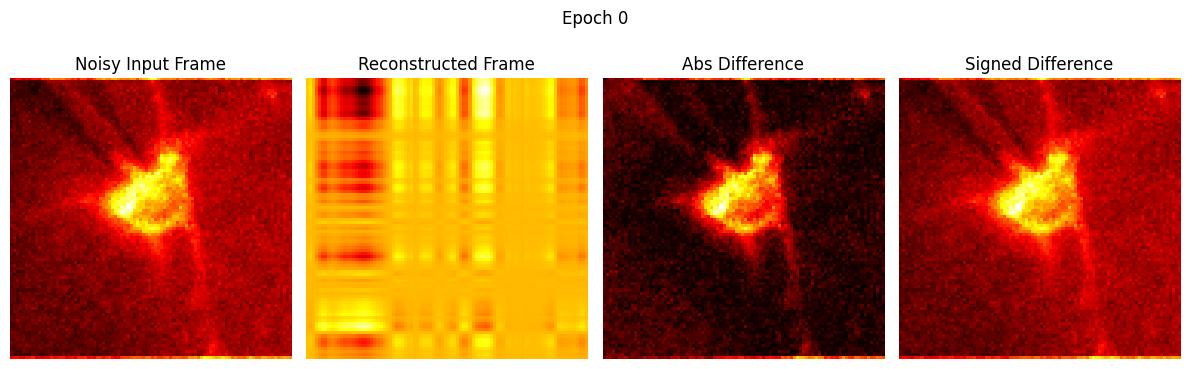

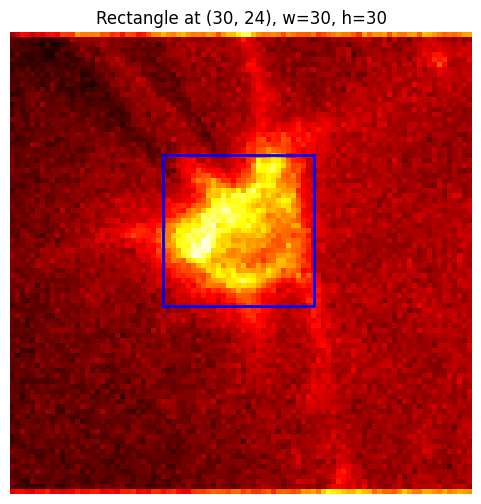

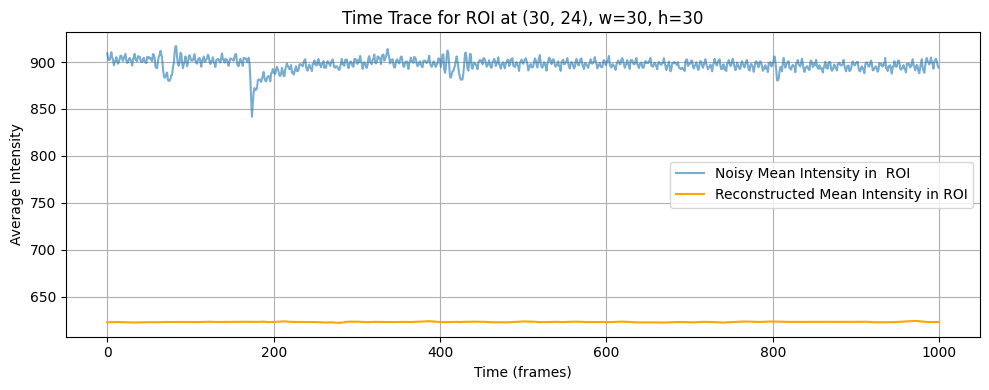

Epoch   10 | loss 5.4432e-01
Epoch   20 | loss 4.3702e-01
Epoch   30 | loss 3.6497e-01
Epoch   40 | loss 3.1487e-01
Epoch   50 | loss 2.7709e-01


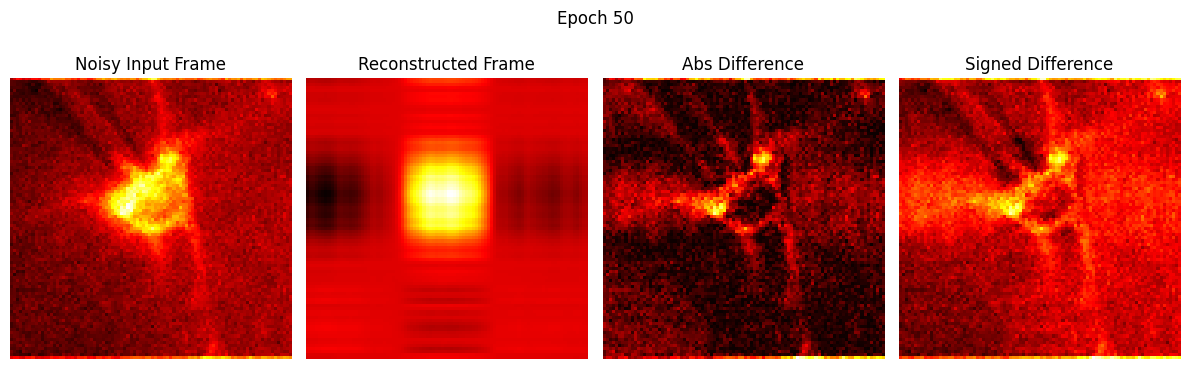

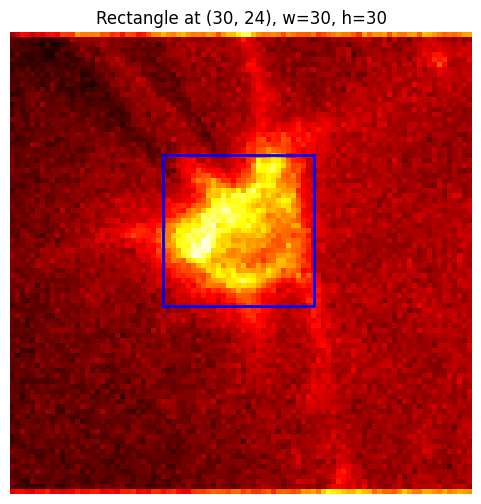

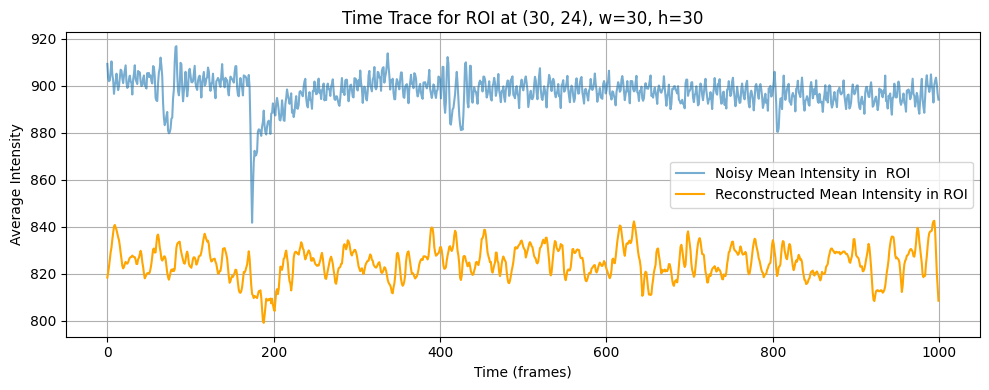

Epoch   60 | loss 2.4491e-01
Epoch   70 | loss 2.1672e-01
Epoch   80 | loss 1.9330e-01
Epoch   90 | loss 1.7666e-01
Epoch  100 | loss 1.6736e-01


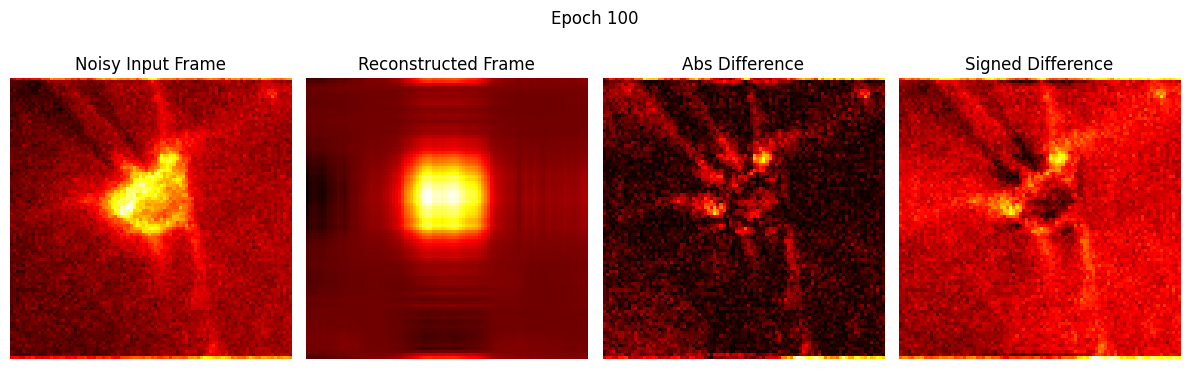

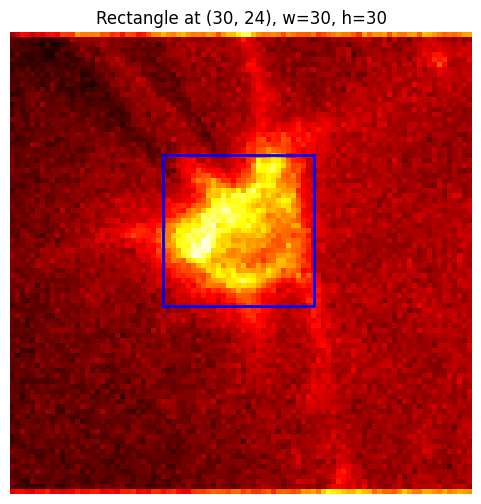

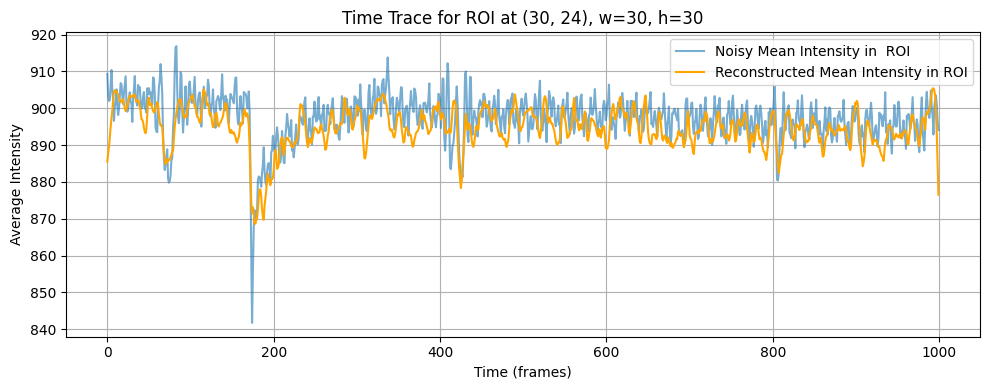

Epoch  110 | loss 1.6065e-01
Epoch  120 | loss 1.5546e-01
Epoch  130 | loss 1.4578e-01
Epoch  140 | loss 1.3536e-01
Epoch  150 | loss 1.2376e-01


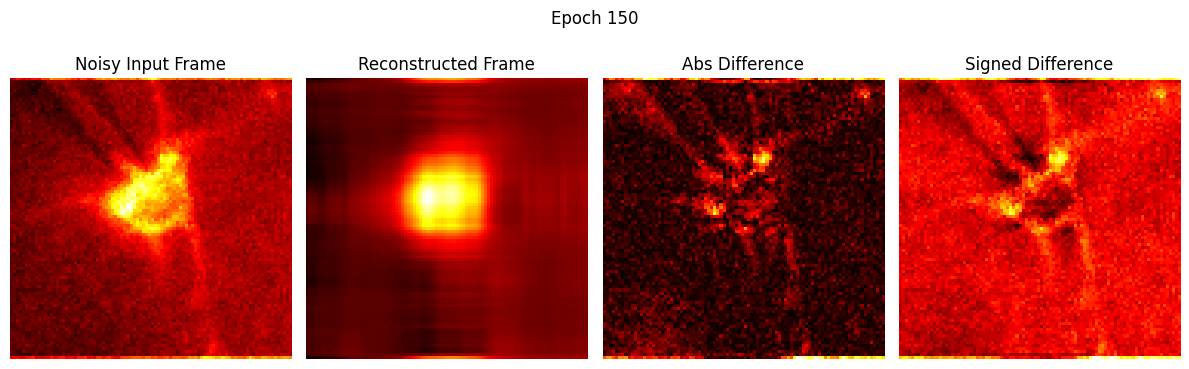

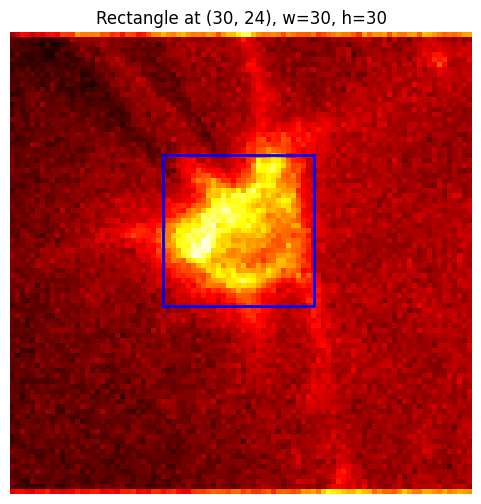

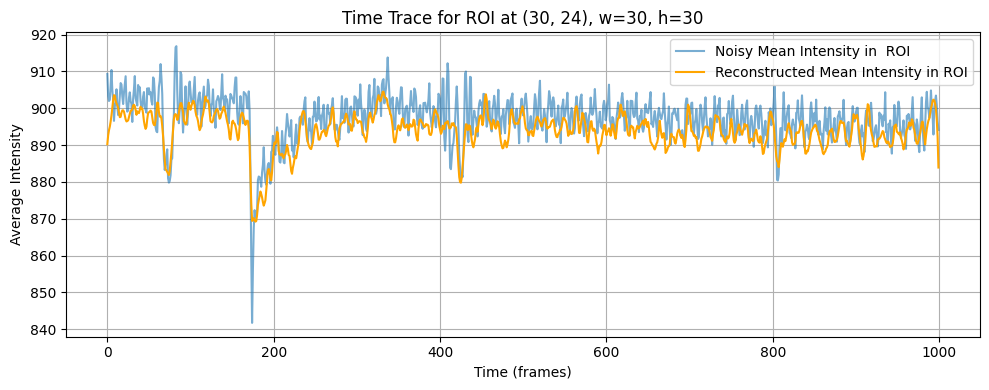

Epoch  160 | loss 1.1371e-01
Epoch  170 | loss 1.0758e-01
Epoch  180 | loss 1.0356e-01
Epoch  190 | loss 1.0158e-01
Epoch  200 | loss 9.6298e-02


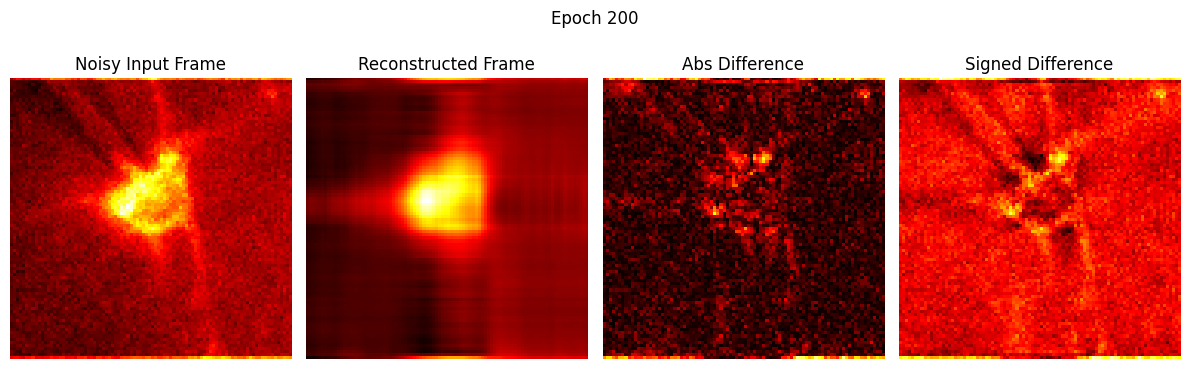

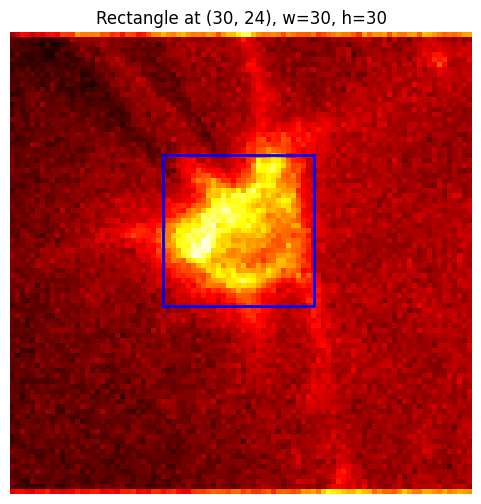

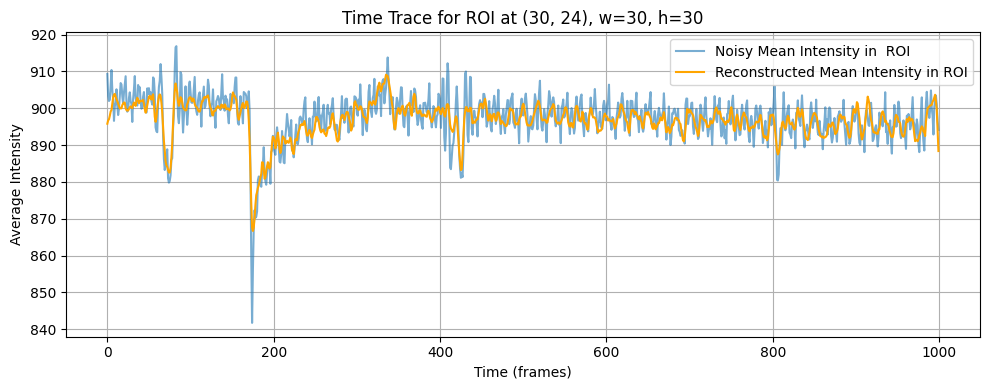

Epoch  210 | loss 9.1390e-02
Epoch  220 | loss 8.7060e-02
Epoch  230 | loss 8.3268e-02
Epoch  240 | loss 7.9350e-02
Epoch  250 | loss 7.6075e-02


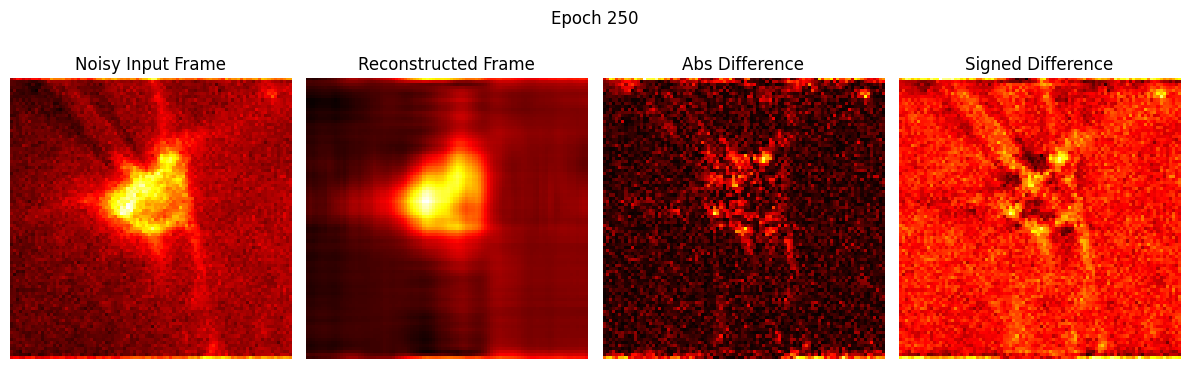

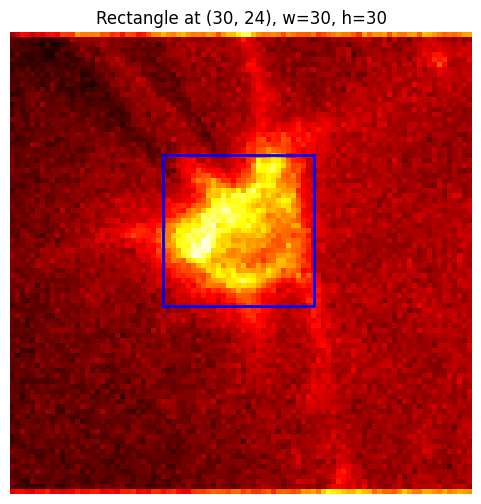

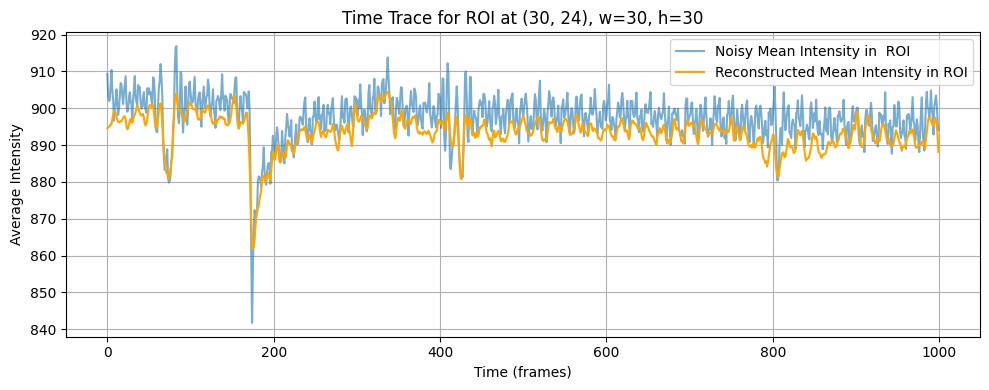

Epoch  260 | loss 7.1342e-02
Epoch  270 | loss 6.8134e-02
Epoch  280 | loss 6.3997e-02
Epoch  290 | loss 6.0777e-02
Epoch  300 | loss 5.6799e-02


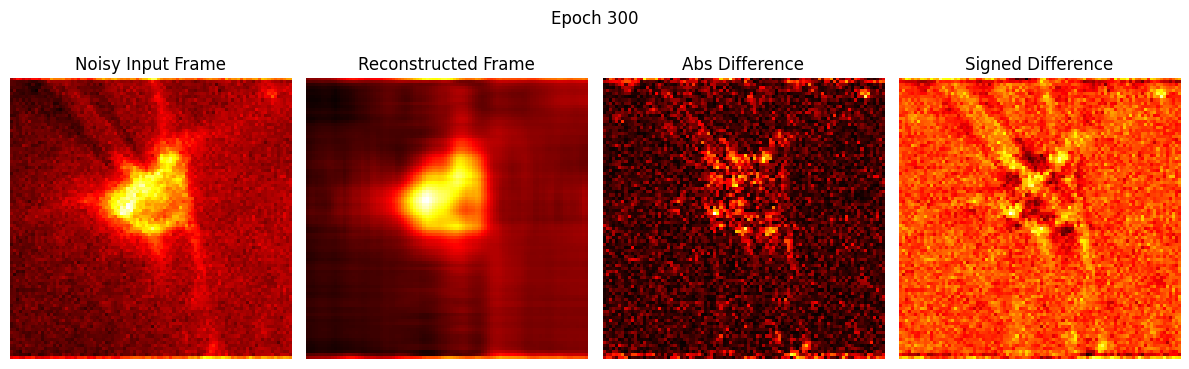

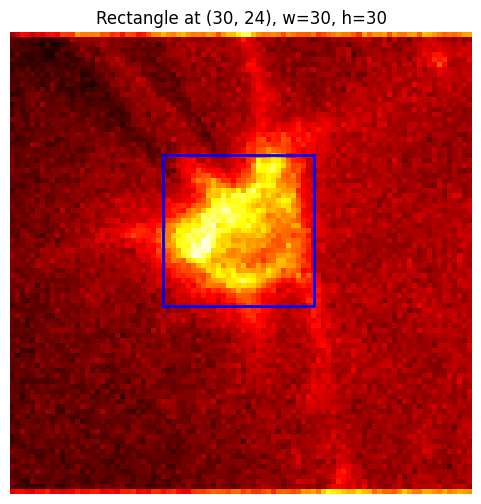

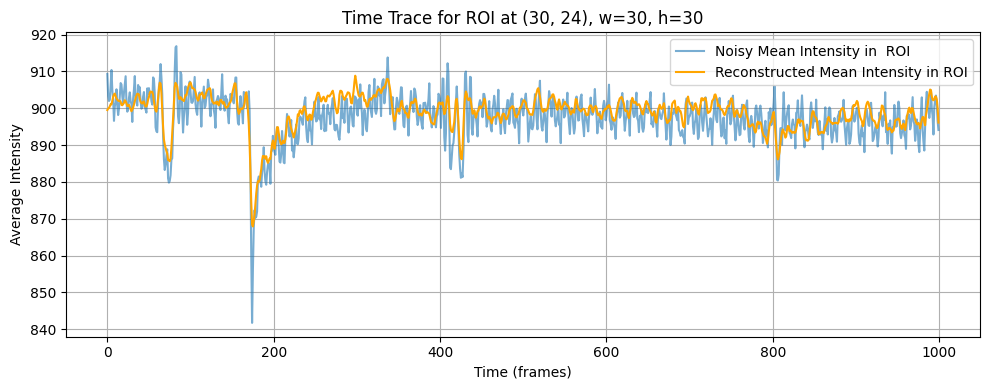

Epoch  310 | loss 5.3881e-02
Epoch  320 | loss 5.1652e-02
Epoch  330 | loss 5.1211e-02
Epoch  340 | loss 4.8769e-02
Epoch  350 | loss 4.6298e-02


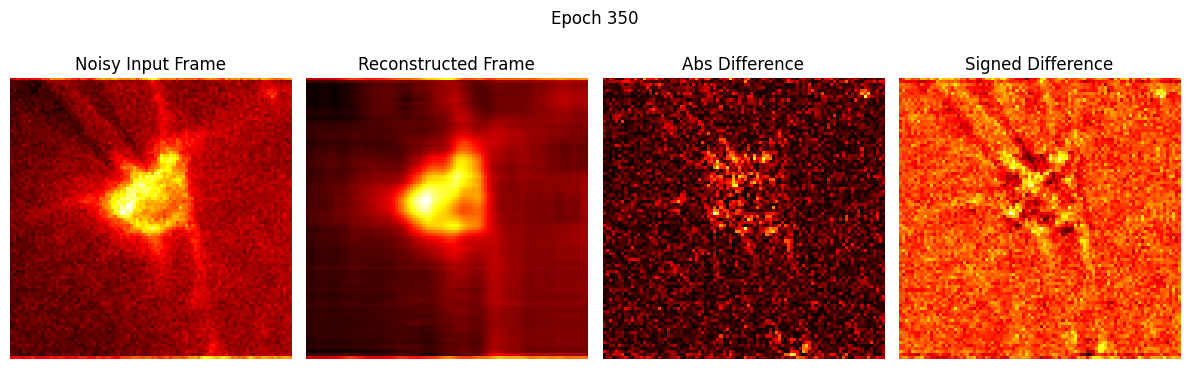

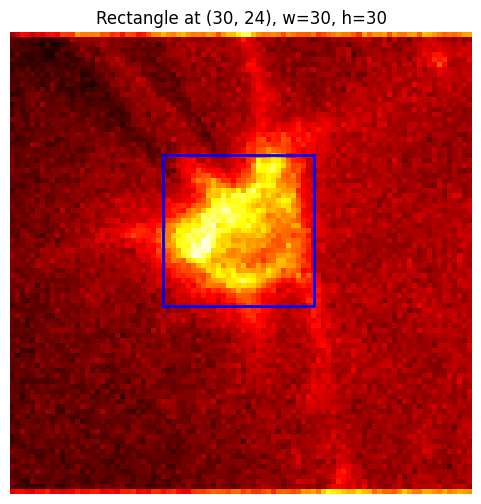

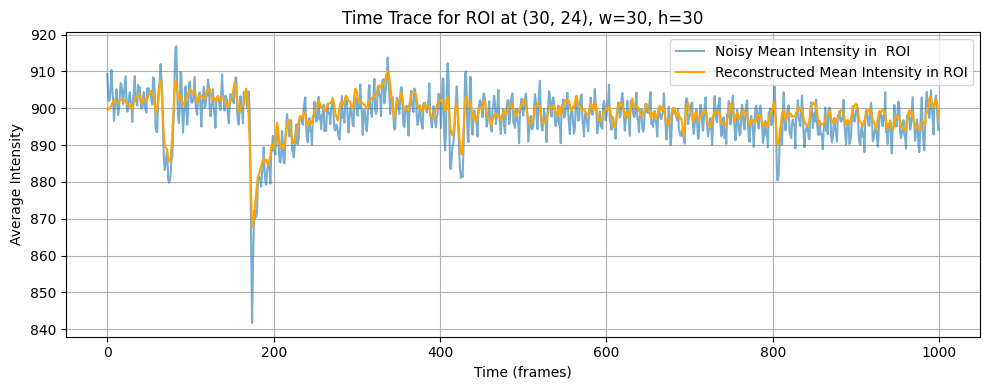

Epoch  360 | loss 4.4654e-02
Epoch  370 | loss 4.3218e-02
Epoch  380 | loss 4.2139e-02
Epoch  390 | loss 4.1186e-02
Epoch  400 | loss 4.0290e-02


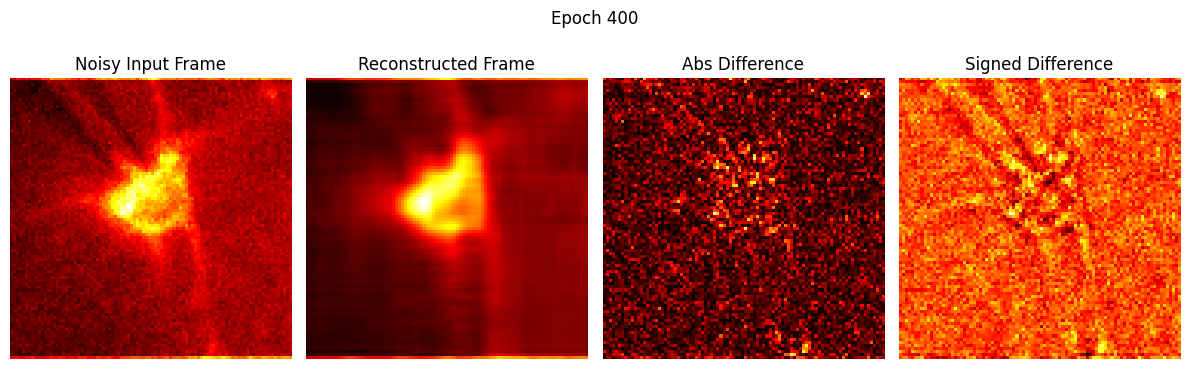

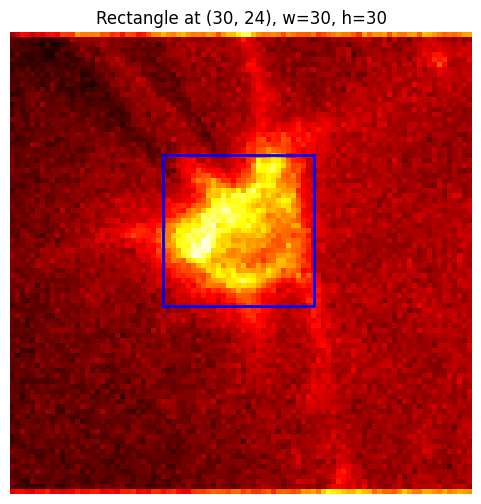

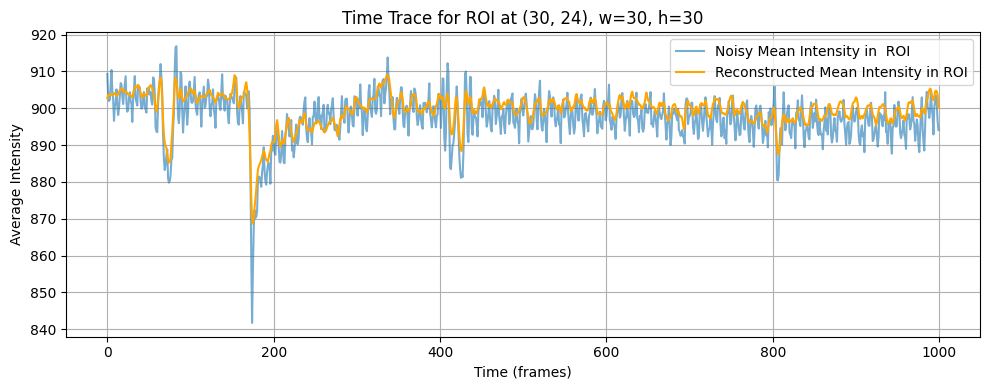

Epoch  410 | loss 3.9419e-02
Epoch  420 | loss 3.8847e-02
Epoch  430 | loss 3.8098e-02
Epoch  440 | loss 3.7571e-02
Epoch  450 | loss 3.7067e-02


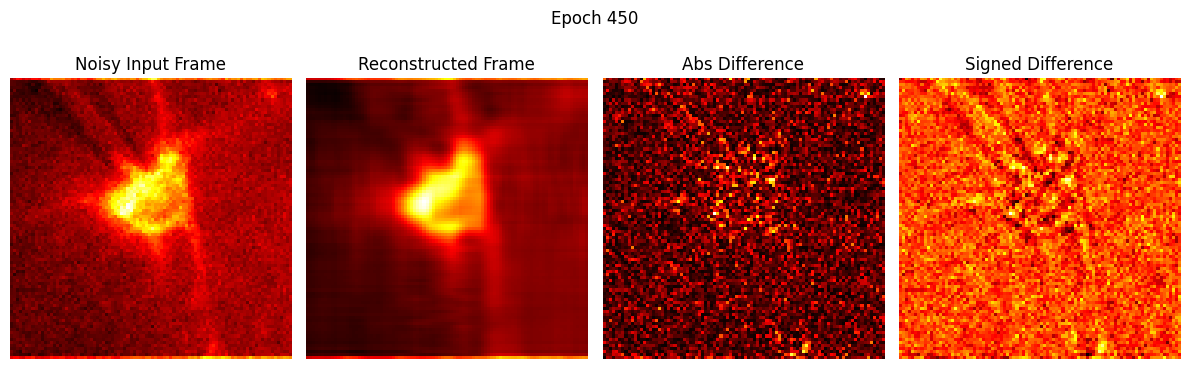

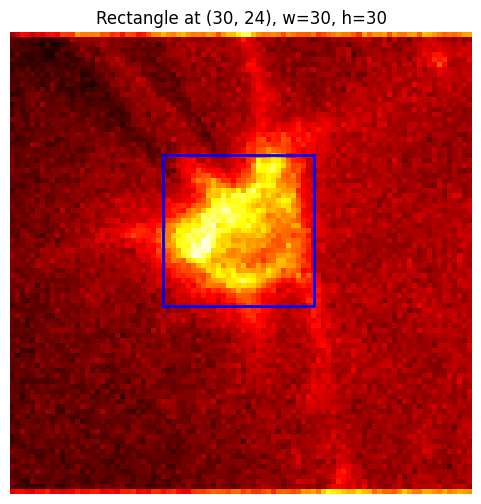

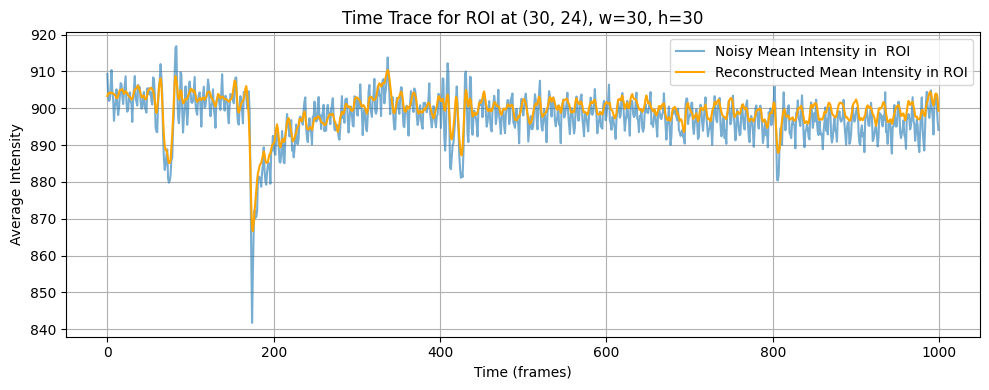

Epoch  460 | loss 3.6420e-02
Epoch  470 | loss 3.5969e-02
Epoch  480 | loss 3.5768e-02
Epoch  490 | loss 3.5776e-02


Text(0.5, 1.0, 'Training Loss Over Epochs')

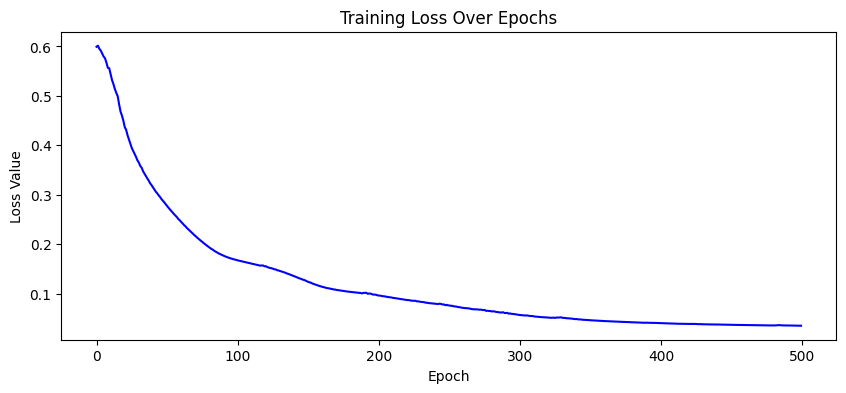

In [2]:

H, W, T = downsampled_video1.shape[1], downsampled_video1.shape[2], downsampled_video1.shape[0]

rank_H = 24
rank_W = 24
rank_T = 24
epochs = 500
learning_rate = 1e-5

# h_inp = nn.Parameter(torch.randn(1, rank_H, H))
# w_inp = nn.Parameter(torch.randn(1, rank_W, W))
# t_inp = nn.Parameter(torch.randn(1, rank_T, T))

h_inp = get_1d_posencode_inp(H, rank_H//2)
w_inp = get_1d_posencode_inp(W, rank_W//2)
t_inp = get_1d_posencode_inp(T, rank_T//2)

# Define parameters for skip1d
skip_n33d = 128  # Number of channels in the downsampling path
skip_n33u = 128  # Number of channels in the upsampling path
skip_n11 = 4   # Number of channels in the skip connection
num_scales = 5  # Number of scales in the skip connection
upsample_mode = 'linear'  # Upsampling mode
downsample_mode = 'stride'  # Downsampling mode
pad = 'reflection'  # Padding mode
act_fun = 'LeakyReLU'  # Activation function
filter_size_up=3
filter_size_down=3 
filter_size_skip=1


h_net = skip1d(
    rank_H,                       # Dimensionality of positional encoding (e.g., 32)
    rank_H,                       # Output dimensionality = Tucker rank (e.g., 32)
    num_channels_down = [skip_n33d]*num_scales if isinstance(skip_n33d, int) else skip_n33d,
    num_channels_up   = [skip_n33u]*num_scales if isinstance(skip_n33u, int) else skip_n33u,
    num_channels_skip = [skip_n11]*num_scales if isinstance(skip_n11, int) else skip_n11,
    upsample_mode     = upsample_mode,
    downsample_mode   = downsample_mode,
    need_sigmoid      = False,
    need_bias         = True,
    pad               = pad,
    act_fun           = act_fun,
    filter_size_up    = filter_size_up,
    filter_size_down  = filter_size_down,
    filter_skip_size  = filter_size_skip
)

w_net = skip1d(
    rank_W,                       # Dimensionality of positional encoding (e.g., 32)
    rank_W,                       # Output dimensionality = Tucker rank (e.g., 32)
    num_channels_down = [skip_n33d]*num_scales if isinstance(skip_n33d, int) else skip_n33d,
    num_channels_up   = [skip_n33u]*num_scales if isinstance(skip_n33u, int) else skip_n33u,
    num_channels_skip = [skip_n11]*num_scales if isinstance(skip_n11, int) else skip_n11,
    upsample_mode     = upsample_mode,
    downsample_mode   = downsample_mode,
    need_sigmoid      = False,
    need_bias         = True,
    pad               = pad,
    act_fun           = act_fun,
    filter_size_up    = filter_size_up,
    filter_size_down  = filter_size_down,
    filter_skip_size  = filter_size_skip
)

t_net = skip1d_fuse_bs(
    rank_T,                       # Dimensionality of positional encoding (e.g., 32)
    rank_T,                       # Output dimensionality = Tucker rank (e.g., 32)
    num_channels_down = [skip_n33d]*num_scales if isinstance(skip_n33d, int) else skip_n33d,
    num_channels_up   = [skip_n33u]*num_scales if isinstance(skip_n33u, int) else skip_n33u,
    num_channels_skip = [skip_n11]*num_scales if isinstance(skip_n11, int) else skip_n11,
    upsample_mode     = upsample_mode,
    downsample_mode   = downsample_mode,
    need_sigmoid      = False,
    need_bias         = True,
    pad               = pad,
    act_fun           = act_fun,
    filter_size_up    = filter_size_up,
    filter_size_down  = filter_size_down,
    filter_skip_size  = filter_size_skip,
    blind_conv_channels=128
)

# Switch to trairning mode
h_net.train()
w_net.train()
t_net.train()

net_params = list(h_net.parameters()) + list(w_net.parameters()) + list(t_net.parameters())
inp_params = [h_inp] + [w_inp] + [t_inp]
params = net_params + inp_params

core = torch.nn.Parameter(torch.ones((rank_T, rank_H, rank_W), dtype=torch.float32) /
    (rank_T * rank_H * rank_W) ** 0.5)
params += [core]

criterion_l1 = L2Norm()
    
loss_array = np.zeros(epochs)
mse_array = np.zeros(epochs)    
time_array = np.zeros(epochs)

optimizer = torch.optim.Adam(lr=learning_rate, params=params)
    
# Create a learning scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size= epochs)

u_inp_per = h_inp.detach().clone()
v_inp_per = w_inp.detach().clone()
w_inp_per = t_inp.detach().clone()

best_loss = float('inf')
best_epoch = 0
tic = time.time()

tbar = tqdm(range(epochs))

frame_idx = 100  # Example frame index to visualize
x, y = 30, 24      # top-left corner (column, row)
width, height = 30, 30

def plot_frame_with_rectangle(frame, x, y, width, height):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(frame, cmap='hot')
    
    # Add rectangle patch
    rect = Rectangle((x, y), width, height, linewidth=2, edgecolor='b', facecolor='none')
    ax.add_patch(rect)

    ax.set_title(f"Rectangle at ({x}, {y}), w={width}, h={height}")
    plt.grid(False)
    plt.axis('off')
    plt.show()

loss_array = np.zeros(epochs)

for idx in tbar:
    A_h = h_net(h_inp).squeeze(0).permute(1, 0)  # [H, 32]
    A_w = w_net(w_inp).squeeze(0).permute(1, 0)  # [W, 32]
    A_t = t_net(t_inp).squeeze(0).permute(1, 0)  # [T, 32]

    # recon = torch.einsum('tr,hr,wr,rxy->thw', A_t, A_h, A_w, core)  # (T,H,W)

    # 1. Multiply along temporal mode (mode-0)
    out = torch.einsum('tr, rhw -> thw', A_t, core)      # [T, R_H, R_W]

    # 2. Multiply along spatial height (mode-1)
    out = torch.einsum('trw, hr -> t w h', out, A_h)     # [T, H, R_W]

    # 3. Multiply along spatial width (mode-2)
    recon = torch.einsum('trh, wr -> thw', out, A_w)     # [T, H, W]

    loss = criterion_l1(downsampled_video1 - recon)

    # Track metrics
    loss_array[idx] = loss.item()
    time_array[idx] = time.time() - tic

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_epoch = idx
        best_reconstruction = recon.detach().clone()

    # Backprop
    optimizer.zero_grad()
    torch.autograd.set_detect_anomaly(True)
    loss.backward()
    optimizer.step()
    scheduler.step()  # optional

    loss_array[idx] = loss.item()

    # Optionally visualize or print
    if idx % 10 == 0:
        print(f'Epoch {idx:4d} | loss {loss.item():.4e}')
    
    if idx % 50 == 0 or idx == 0:
        recon_scaled = recon* std_val + mean_val
        video_scaled = downsampled_video1 * std_val + mean_val
        recon_frame = recon_scaled[frame_idx].detach().cpu().numpy()
        gt_frame = video_scaled[frame_idx].detach().cpu().numpy()

        diff_frame = np.abs(gt_frame - recon_frame)
        diff_frame_signed = gt_frame - recon_frame

        fig, axs = plt.subplots(1, 4, figsize=(12, 4))
        axs[0].imshow(gt_frame, cmap='hot')
        axs[0].set_title('Noisy Input Frame')
        axs[0].axis('off')

        axs[1].imshow(recon_frame, cmap='hot')
        axs[1].set_title('Reconstructed Frame')
        axs[1].axis('off')

        axs[2].imshow(diff_frame, cmap='hot')
        axs[2].set_title('Abs Difference')
        axs[2].axis('off')

        axs[3].imshow(diff_frame_signed, cmap='hot')
        axs[3].set_title('Signed Difference')
        axs[3].axis('off')

        plt.suptitle(f'Epoch {idx}')
        plt.tight_layout()
        plt.show()

        plot_frame_with_rectangle(gt_frame, x, y, width, height)

        # Extract the patch over time (shape: T x height x width)
        patch_noisy = video_scaled[:, y:y+height, x:x+width]  # shape: (T, h, w)
        patch_recon = recon_scaled[:, y:y+height, x:x+width]

        # Average over spatial dimensions
        avg_trace_noisy = patch_noisy.mean(dim=(1, 2)).detach().cpu().numpy()
        avg_trace_recon = patch_recon.mean(dim=(1, 2)).detach().cpu().numpy()

        # Plot the time trace
        plt.figure(figsize=(10, 4))
        plt.plot(avg_trace_noisy, label='Noisy Mean Intensity in  ROI', alpha=0.6)
        plt.plot(avg_trace_recon, label='Reconstructed Mean Intensity in ROI', color='orange')
        plt.xlabel("Time (frames)")
        plt.ylabel("Average Intensity")
        plt.title(f"Time Trace for ROI at ({x}, {y}), w={width}, h={height}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

#plot loss
plt.figure(figsize=(10, 4))
plt.plot(loss_array, label='Loss', color='blue')
plt.xlabel("Epoch")
plt.ylabel("Loss Value")
plt.title("Training Loss Over Epochs")
